# 11. z 変換 — 離散の世界への橋渡し

| 層 | セクション |
|---|---|
| — | サンプリング・z 変換・s→z 写像・離散の安定性 |

> サンプリングで連続→離散へ。$z=e^{sT}$ が s 平面を z 平面へ写し、左半面 → 単位円内、安定性も対応する。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture — サンプリングと z 変換

連続信号を一定間隔 $T$ で **標本化** すると、時間は数列 $x[k]=x(kT)$ になる。連続のラプラス変換に
対応するのが **z 変換**

$$ X(z) = \sum_{k=0}^{\infty} x[k]\, z^{-k}, $$

そして両者は $z=e^{sT}$ で結ばれる。本章はラプラスから離散の世界への橋渡し(入口)。

## 2. Problem / 3. Intuition

離散の漸化式(差分方程式)も $z$ 領域では代数になる(微分が掛け算になったのと同じ構図)。
$z^{-1}$ は **1サンプルの遅延**。連続の固有関数 $e^{st}$ の役を、離散では $z^k=e^{skT}$ が担う。

## 4. Definition と 幾何級数ペア

最重要ペアは幾何数列 $a^k$:

$$ \sum_{k=0}^{\infty} a^k z^{-k} = \frac{z}{z-a} \quad (|z|>|a|). $$

連続の $e^{-\alpha t}\leftrightarrow 1/(s+\alpha)$ の離散版。`discrete.numeric_ztransform` で確認する。

In [2]:
seq = discrete.geometric_sequence(0.5, 300)        # 0.5^k
for z in [2.0, 1.5, 1.0 + 1j]:
    num = discrete.numeric_ztransform(seq, z)
    exact = complex(z) / (complex(z) - 0.5)
    print(f"z={z}:  numeric={num:.4f}   z/(z-a)={exact:.4f}")

z=2.0:  numeric=1.3333+0.0000j   z/(z-a)=1.3333+0.0000j
z=1.5:  numeric=1.5000+0.0000j   z/(z-a)=1.5000+0.0000j
z=(1+1j):  numeric=1.2000-0.4000j   z/(z-a)=1.2000-0.4000j


## 5. s 平面 → z 平面($z=e^{sT}$)

$z=e^{sT}$ は s 平面を z 平面へ巻きつける写像。一定 $\sigma$ の縦線は半径 $e^{\sigma T}$ の円になり、
**左半面($\sigma<0$)→ 単位円の内側**、**虚軸 → 単位円**、右半面 → 外側。

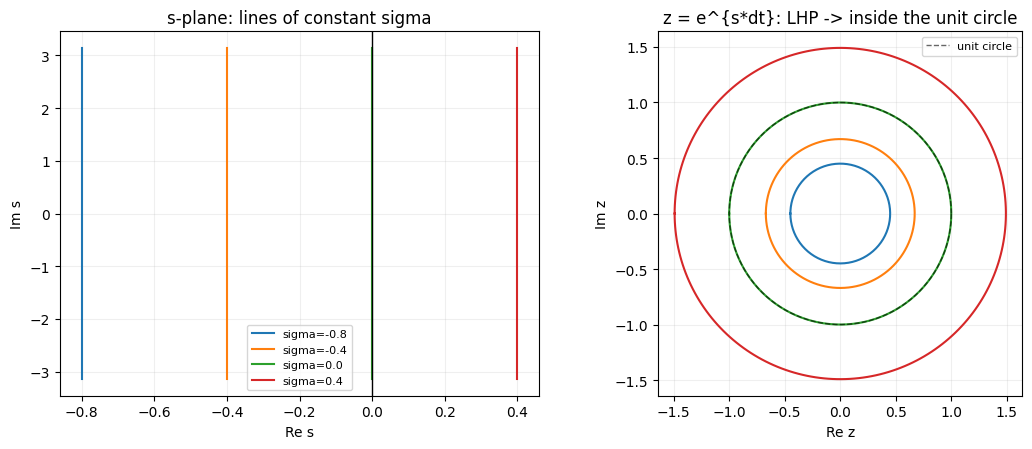

In [3]:
dt = 1.0
omega = np.linspace(-np.pi, np.pi, 240)            # one Nyquist band
fig, (axs, axz) = plt.subplots(1, 2, figsize=(11, 4.6))
for sig in [-0.8, -0.4, 0.0, 0.4]:
    s = sig + 1j * omega
    axs.plot(s.real, s.imag, label=f"sigma={sig}")
    z = discrete.s_to_z(s, dt)
    axz.plot(z.real, z.imag)
th = np.linspace(0, 2 * np.pi, 240)
axz.plot(np.cos(th), np.sin(th), "k--", lw=1, alpha=0.6, label="unit circle")
axs.axvline(0, color="k", lw=1); axs.set_title("s-plane: lines of constant sigma")
axs.set_xlabel("Re s"); axs.set_ylabel("Im s"); axs.legend(fontsize=8); axs.grid(alpha=0.2)
axz.set_title("z = e^{s*dt}: LHP -> inside the unit circle")
axz.set_xlabel("Re z"); axz.set_ylabel("Im z"); axz.set_aspect("equal")
axz.legend(fontsize=8); axz.grid(alpha=0.2)
plt.tight_layout()

## 6. 離散の安定性とステップ応答

連続では「極が左半面」で安定。離散では **極が単位円の内側** $|z|<1$ なら安定。
`discrete.is_stable_discrete` が判定する。

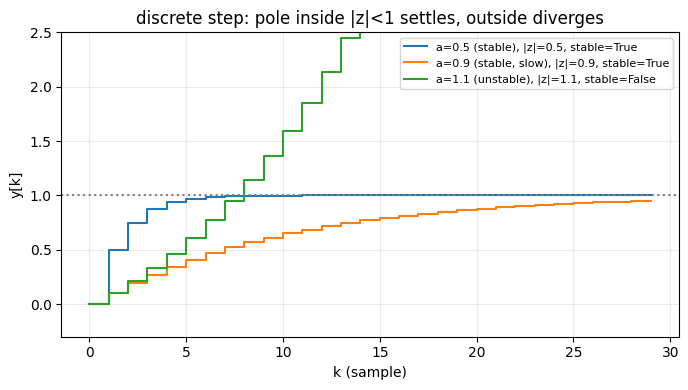

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for a, lab in [(0.5, "a=0.5 (stable)"), (0.9, "a=0.9 (stable, slow)"), (1.1, "a=1.1 (unstable)")]:
    b = (1.0 - a) if a < 1 else 0.1                # gain so a stable system has DC gain 1
    sysd = discrete.discrete_tf([b], [1.0, -a], dt=1.0)
    k, y = discrete.discrete_step_response(sysd, n=30)
    ax.step(k, y, where="post", label=f"{lab}, |z|={a}, stable={discrete.is_stable_discrete(sysd)}")
ax.axhline(1.0, color="gray", ls=":"); ax.set_ylim(-0.3, 2.5)
ax.set_xlabel("k (sample)"); ax.set_ylabel("y[k]")
ax.set_title("discrete step: pole inside |z|<1 settles, outside diverges")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

## 7. ラプラスとの対応(まとめ)

| 連続(ラプラス) | 離散(z 変換) |
|---|---|
| $\mathcal{L}\{f\}=\int_0^\infty f e^{-st}dt$ | $X(z)=\sum_k x[k] z^{-k}$ |
| $e^{-\alpha t}\leftrightarrow 1/(s+\alpha)$ | $a^k \leftrightarrow z/(z-a)$ |
| 微分 → $s$ 倍 | 1サンプル遅延 → $z^{-1}$ 倍 |
| 安定 ⇔ 極が左半面 | 安定 ⇔ 極が単位円内 |
| 虚軸 = フーリエ変換 | 単位円 = 離散時間フーリエ(DTFT) |

橋は $z=e^{sT}$。サンプリング定理・エイリアシングは続編へ。

## 8. Exercises / TODO

- **Basic**: $x[k]=2^{-k}$ の z 変換を求め、収束域 $|z|>1/2$ を述べよ。
- **Applied**: 差分方程式 $y[k]-0.8\,y[k-1]=x[k]$ の伝達関数 $H(z)=1/(1-0.8z^{-1})$ を作り、
  `discrete` でステップ応答を描け。
- **Advanced**: 双一次変換 $s=\frac{2}{T}\frac{z-1}{z+1}$ による連続→離散の離散化をまとめよ。

> **TODO(今後の拡張)**: サンプリング定理・エイリアシング、DTFT/DFT、双一次変換によるフィルタ設計、
> 連続コントローラの離散化を追加。